# Empirical Methods in Finance — Lab (Python)

**Topic:** Moments (1–4), autocorrelation, cross-asset correlation, and *aggregational normality*  
**Data:** `Data_HEC2.xlsx` (Daily + Lower Freq)

**Learning goals**
1. Compute *central moments* (mean, variance, skewness, kurtosis) on return series.
2. Visualise serial dependence: ACF, Ljung–Box, volatility clustering (ACF of squared/absolute returns).
3. Measure cross-asset dependence: correlation matrices and heatmaps.
4. Show that *sampling frequency matters*: as we go to lower frequency, returns look “more Gaussian” (often higher p-values in normality tests).
5. Connect changing return properties to *horizon-dependent portfolio allocation* (Campbell–Shiller intuition: long-horizon equity share can rise when risk per unit time falls due to mean reversion).

> **Note:** The lab uses log-returns (in %) unless stated otherwise.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.optimize import minimize
from typing import Sequence

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Make plots readable
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


## 1. Load the data

In [2]:
xlsx_path = "Data_HEC2.xlsx"

# Inspect available sheets
xl = pd.ExcelFile(xlsx_path)
xl.sheet_names


['Daily', 'Lower Freq']

In [3]:
daily = pd.read_excel(xlsx_path, sheet_name="Daily",index_col=0)
low  = pd.read_excel(xlsx_path, sheet_name="Lower Freq",index_col=0)

daily.head(), low.head()


(            Global Treasury Bonds  Global Aggregate Bonds   S&P500  \
 2001-01-16                 105.17                240.1840  1326.65   
 2001-01-17                 105.32                240.5928  1329.47   
 2001-01-18                 105.60                241.2803  1347.97   
 2001-01-19                 105.49                241.0037  1342.54   
 2001-01-22                 105.52                240.9910  1342.90   
 
             Dollar Index    Gold      Oil  
 2001-01-16        110.11  263.55  85.1728  
 2001-01-17        110.67  263.55  83.0809  
 2001-01-18        109.94  264.55  85.6809  
 2001-01-19        110.67  264.75  90.2234  
 2001-01-22        110.14  266.95  89.0579  ,
              AAA Bonds   BBB Bonds    Equities
 1927-12-31  100.000000  100.000000  100.000000
 1928-01-31  100.371667  100.153333   99.490374
 1928-02-29  100.744715  100.710019   97.734994
 1928-03-31  101.119149  101.187552  109.173273
 1928-04-30  101.494975  101.504607  111.834655)

### 1.1 Clean date columns

In both sheets, the date column is stored as `Unnamed: 0`.  
We convert it to a proper `DatetimeIndex`, sort, and keep only numeric asset columns.


In [4]:
daily_px = daily
low_px   = low

daily_px.tail(), low_px.tail()


(            Global Treasury Bonds  Global Aggregate Bonds   S&P500  \
 2026-02-13                 257.10                615.0287  6836.17   
 2026-02-17                 257.49                615.6633  6843.22   
 2026-02-18                 257.38                615.3505  6881.31   
 2026-02-19                 257.41                615.4227  6861.89   
 2026-02-20                 257.55                615.7339  6909.51   
 
             Dollar Index     Gold    Oil  
 2026-02-13        96.915  5042.04  62.75  
 2026-02-17        97.155  4877.89  62.26  
 2026-02-18        97.703  4977.56  65.05  
 2026-02-19        97.925  4996.10  66.40  
 2026-02-20        97.796  5107.45  66.48  ,
                AAA Bonds     BBB Bonds      Equities
 2025-05-31  19970.316110  30955.358931  33475.028313
 2025-06-30  20190.322425  31448.838945  35135.617214
 2025-07-31  20298.340650  31720.085181  35896.885617
 2025-08-31  20552.915673  32119.229586  36581.313703
 2025-09-30  20874.740077  32700.5876

## 2. Daily data (≈25 years): returns, moments 1–4, autocorrelograms, cross-correlations
The Daily sheet contains **price indices**. We transform them into **log-returns**:

\[
r_t = 100\times\left(\log P_t - \log P_{t-1}\right)
\]

(returns in percent)


In [5]:
daily_ret = 100 * np.log(daily_px).diff().dropna()
daily_ret.describe().T


,count,mean,std,min,25%,50%,75%,max
Global Treasury Bonds,6285.0,0.014250,0.172976,-1.079221,-0.083405,0.018436,0.114785,0.996820
Global Aggregate Bonds,6285.0,0.014979,0.182178,-1.468240,-0.085309,0.022701,0.121801,1.311146
S&P500,6285.0,0.026257,1.211433,-12.765214,-0.455573,0.068511,0.581294,10.957196
Dollar Index,6285.0,-0.001887,0.485466,-2.726254,-0.279482,0.000000,0.272524,2.519905
Gold,6285.0,0.047163,1.096712,-9.512069,-0.496941,0.064916,0.637422,10.245144
Oil,6285.0,-0.003942,2.552361,-56.858440,-1.225673,0.090788,1.240442,22.393996


### 2.1 Central moments (1–4) + skewness / kurtosis

In [6]:
def moment_table(ret: pd.DataFrame) -> pd.DataFrame:
    # Central moments: mean, variance, 3rd, 4th + standardized skew/kurt
    mu = ret.mean()
    var = ret.var(ddof=0)  # ML estimator (matches many finance slides)
    std = np.sqrt(var)

    centered = ret.sub(mu, axis=1)
    mu3 = (centered**3).mean()
    mu4 = (centered**4).mean()

    skew = mu3 / (std**3)
    kurt = mu4 / (std**4)  # normal => 3

    out = pd.DataFrame({
        "mean": mu,
        "variance": var,
        "stdev": std,
        "mu3": mu3,
        "mu4": mu4,
        "skewness": skew,
        "kurtosis": kurt,
        "excess_kurtosis": kurt - 3.0
    })
    return out

mom_daily = moment_table(daily_ret)
mom_daily


,mean,variance,stdev,mu3,mu4,skewness,kurtosis,excess_kurtosis
Global Treasury Bonds,0.014250,0.029916,0.172962,-0.000379,0.004678,-0.073166,5.227530,2.227530
Global Aggregate Bonds,0.014979,0.033183,0.182163,-0.001257,0.006513,-0.207966,5.915010,2.915010
S&P500,0.026257,1.467338,1.211337,-0.672867,30.744645,-0.378560,14.279383,11.279383
Dollar Index,-0.001887,0.235640,0.485428,-0.003890,0.264580,-0.034007,4.764962,1.764962
Gold,0.047163,1.202587,1.096625,-0.496417,13.150387,-0.376419,9.092968,6.092968
Oil,-0.003942,6.513509,2.552158,-35.326160,2315.519184,-2.125073,54.578087,51.578087


**Quick interpretation**
- Skewness < 0: fatter *left* tail (crash risk).
- Kurtosis > 3: fat tails vs Normal.


### 2.2 Normality tests (Jarque–Bera + Anderson–Darling)

In [7]:
def normality_tests(ret: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in ret.columns:
        x = ret[c].dropna().values
        jb_stat, jb_p = stats.jarque_bera(x)
        ad = stats.anderson(x, dist="norm")  # provides critical values but no p-value
        rows.append({
            "asset": c,
            "JB_stat": jb_stat,
            "JB_pvalue": jb_p,
            "AD_stat": ad.statistic,
            # AD critical values are for significance levels in ad.significance_level
            "AD_5pct_crit": float(ad.critical_values[list(ad.significance_level).index(5.0)]),
            "reject_norm_AD_5pct": ad.statistic > ad.critical_values[list(ad.significance_level).index(5.0)]
        })
    return pd.DataFrame(rows).set_index("asset").sort_values("JB_pvalue")

tests_daily = normality_tests(daily_ret)
tests_daily


C:\Users\TOTO2\AppData\Local\Temp\ipykernel_37620\303093282.py:6: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(x, dist="norm")  # provides critical values but no p-value


,JB_stat,JB_pvalue,AD_stat,AD_5pct_crit,reject_norm_AD_5pct
asset,,,,,
Global Aggregate Bonds,2270.530290,0.000000e+00,27.691278,0.752,True
S&P500,33467.027553,0.000000e+00,127.666315,0.752,True
Oil,701396.264747,0.000000e+00,87.617917,0.752,True
Gold,9870.338460,0.000000e+00,53.885349,0.752,True
Global Treasury Bonds,1305.002185,4.191563e-284,22.580669,0.752,True
Dollar Index,816.975780,3.944241e-178,20.099368,0.752,True


### 2.3 Autocorrelograms (returns vs squared returns)

We typically see:
- **Returns**: little or no linear autocorrelation.
- **Squared / absolute returns**: positive autocorrelation (volatility clustering).


In [8]:
asset = daily_ret.columns[0]  # change if you want a different asset
asset


'Global Treasury Bonds'

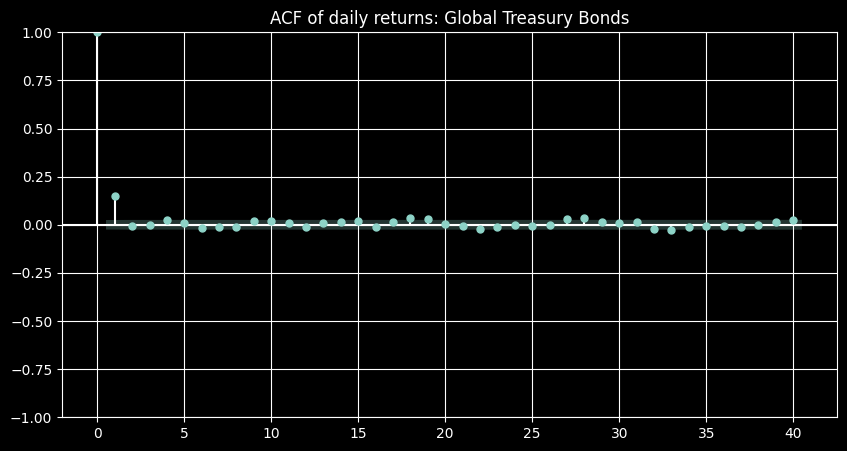

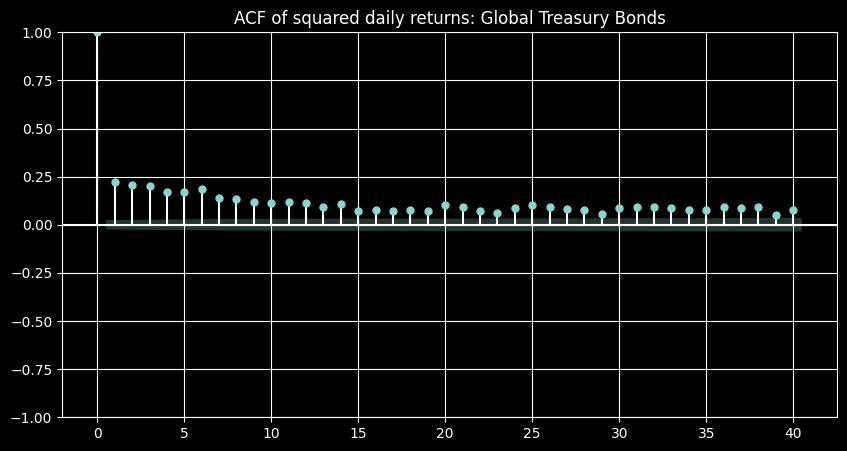

(             Q        pvalue
 5   142.714254  4.738165e-29
 10  150.035727  3.664932e-27
 20  173.454487  1.842583e-26
 40  210.921167  4.343786e-25,
               Q         pvalue
 5   1199.861800  3.147180e-257
 10  1816.609924   0.000000e+00
 20  2339.822436   0.000000e+00
 40  3207.603758   0.000000e+00)

In [9]:
x = daily_ret[asset].dropna()

# ACF of returns
plot_acf(x, lags=40)
plt.title(f"ACF of daily returns: {asset}")
plt.show()

# ACF of squared returns (volatility proxy)
plot_acf(x**2, lags=40)
plt.title(f"ACF of squared daily returns: {asset}")
plt.show()

# Ljung–Box tests for the null: first p autocorrelations are zero
lb_ret = acorr_ljungbox(x, lags=[5,10,20,40], return_df=True)
lb_sq  = acorr_ljungbox(x**2, lags=[5,10,20,40], return_df=True)

lb_ret.rename(columns={"lb_stat":"Q", "lb_pvalue":"pvalue"}), lb_sq.rename(columns={"lb_stat":"Q", "lb_pvalue":"pvalue"})


### 2.4 Cross-asset correlations (heatmap)

In [10]:
corr_daily = daily_ret.corr()
corr_daily


,Global Treasury Bonds,Global Aggregate Bonds,S&P500,Dollar Index,Gold,Oil
Global Treasury Bonds,1.000000,0.970878,-0.202906,-0.139655,0.185069,-0.135518
Global Aggregate Bonds,0.970878,1.000000,-0.159745,-0.182260,0.202293,-0.115277
S&P500,-0.202906,-0.159745,1.000000,-0.107670,0.014871,0.245479
Dollar Index,-0.139655,-0.182260,-0.107670,1.000000,-0.437475,-0.158640
Gold,0.185069,0.202293,0.014871,-0.437475,1.000000,0.187969
Oil,-0.135518,-0.115277,0.245479,-0.158640,0.187969,1.000000


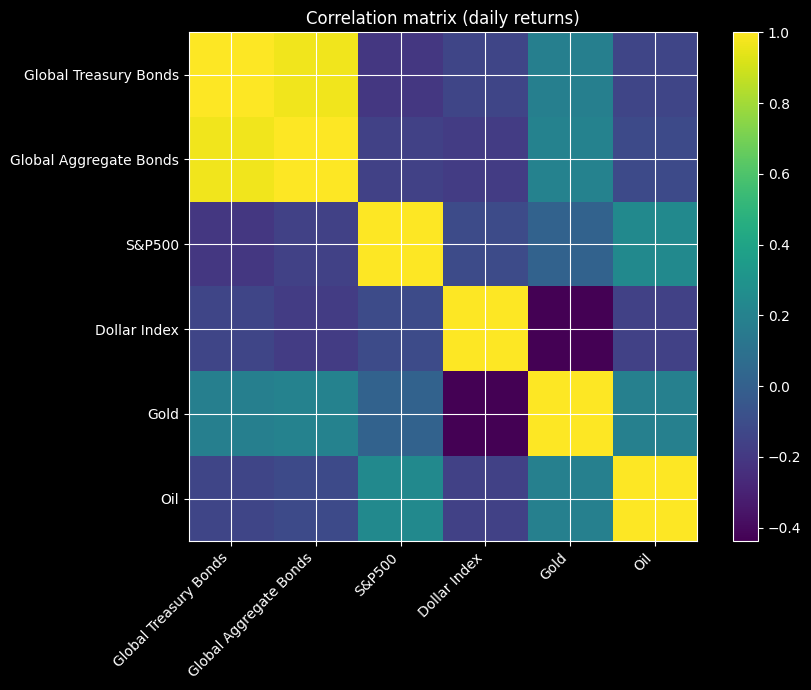

In [11]:
plt.figure(figsize=(9,7))
plt.imshow(corr_daily.values)
plt.xticks(range(len(corr_daily.columns)), corr_daily.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_daily.index)), corr_daily.index)
plt.colorbar()
plt.title("Correlation matrix (daily returns)")
plt.tight_layout()
plt.show()


## 3. Sampling frequency and “aggregational normality” on the Daily dataset

We resample daily prices into weekly and monthly prices, then compute returns.  
We compare moments and Jarque–Bera p-values across frequencies.

> The key idea is that as you aggregate returns over longer horizons, the distribution often looks more Normal.


In [14]:
def resampled_log_returns(px: pd.DataFrame, rule: str) -> pd.DataFrame:
    # rule examples: "W-FRI" (weekly), "M" (month end)
    px_r = px.resample(rule).last()
    ret = 100 * np.log(px_r).diff().dropna()
    return ret

weekly_ret  = resampled_log_returns(daily_px, "W-FRI")
monthly_ret = resampled_log_returns(daily_px, "ME")

mom_weekly  = moment_table(weekly_ret).add_prefix("W_")
mom_monthly = moment_table(monthly_ret).add_prefix("M_")

# Merge key stats
compare = pd.concat([mom_daily[["skewness","kurtosis","excess_kurtosis"]],
                     mom_weekly[["W_skewness","W_kurtosis","W_excess_kurtosis"]],
                     mom_monthly[["M_skewness","M_kurtosis","M_excess_kurtosis"]]], axis=1)

compare


,skewness,kurtosis,excess_kurtosis,W_skewness,W_kurtosis,W_excess_kurtosis,M_skewness,M_kurtosis,M_excess_kurtosis
Global Treasury Bonds,-0.073166,5.227530,2.227530,-0.227413,4.102674,1.102674,-0.069696,3.328374,0.328374
Global Aggregate Bonds,-0.207966,5.915010,2.915010,-0.439125,5.179856,2.179856,-0.267126,4.137406,1.137406
S&P500,-0.378560,14.279383,11.279383,-0.896394,10.599355,7.599355,-0.732836,4.289626,1.289626
Dollar Index,-0.034007,4.764962,1.764962,0.115673,4.327756,1.327756,0.048867,3.515266,0.515266
Gold,-0.376419,9.092968,6.092968,-0.209728,4.929757,1.929757,-0.158416,3.612947,0.612947
Oil,-2.125073,54.578087,51.578087,-0.890497,9.593804,6.593804,-1.302622,14.230043,11.230043


In [15]:
def jb_pvalues(ret: pd.DataFrame) -> pd.Series:
    return pd.Series({c: stats.jarque_bera(ret[c].dropna().values).pvalue for c in ret.columns})

jb_daily   = jb_pvalues(daily_ret).rename("JB_p_daily")
jb_weekly  = jb_pvalues(weekly_ret).rename("JB_p_weekly")
jb_monthly = jb_pvalues(monthly_ret).rename("JB_p_monthly")

pd.concat([jb_daily.round(2), jb_weekly.round(2), jb_monthly.round(2)], axis=1).sort_values("JB_p_daily")


,JB_p_daily,JB_p_weekly,JB_p_monthly
Global Treasury Bonds,0.0,0.0,0.45
Global Aggregate Bonds,0.0,0.0,0.00
S&P500,0.0,0.0,0.00
Dollar Index,0.0,0.0,0.18
Gold,0.0,0.0,0.05
Oil,0.0,0.0,0.00


## 4. Long-run data (Lower Freq): how lower frequency changes statistical properties

The `Lower Freq` sheet is a long historical dataset (monthly index levels).  
We compute:
- monthly log-returns
- quarterly log-returns (3-month)
- annual log-returns (12-month)

Then we compare moments and normality tests across horizons.


In [19]:
low_m = 100 * np.log(low_px).diff().dropna()         # monthly log returns
low_q = 100 * np.log(low_px.resample("QE").last()).diff().dropna()  # quarterly
low_y = 100 * np.log(low_px.resample("YE").last()).diff().dropna()  # annual

low_m.head(), low_q.head(), low_y.head()


(            AAA Bonds  BBB Bonds   Equities
 1928-01-31   0.370978   0.153216  -0.510929
 1928-02-29   0.370978   0.554294  -1.780122
 1928-03-31   0.370978   0.473046  11.067660
 1928-04-30   0.370978   0.312843   2.408520
 1928-05-31   0.131580  -0.326365   1.257878,
             AAA Bonds  BBB Bonds   Equities
 1928-03-31   1.112933   1.180556   8.776609
 1928-06-30   0.236370  -0.653901  -0.728790
 1928-09-30   0.829589   0.923037   9.938659
 1928-12-31   1.147224   1.159972  14.136487
 1929-03-31   0.436994  -0.264736   4.732238,
             AAA Bonds  BBB Bonds   Equities
 1928-12-31   3.326116   2.609664  32.122965
 1929-12-31   4.226819   2.451750 -12.680720
 1930-12-31   5.739633  -0.967700 -33.526085
 1931-12-31  -1.995048 -24.202553 -63.613364
 1932-12-31  10.762556  21.019249 -15.991438)

<Axes: >

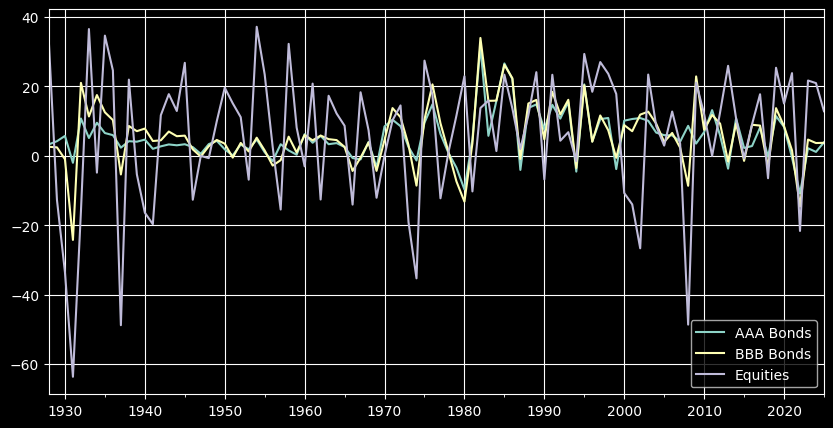

In [20]:
low_y.plot()

In [21]:
mom_m = moment_table(low_m).add_prefix("M_")
mom_q = moment_table(low_q).add_prefix("Q_")
mom_y = moment_table(low_y).add_prefix("Y_")

moments_low = pd.concat([
    mom_m[["M_skewness","M_kurtosis","M_excess_kurtosis"]],
    mom_q[["Q_skewness","Q_kurtosis","Q_excess_kurtosis"]],
    mom_y[["Y_skewness","Y_kurtosis","Y_excess_kurtosis"]],
], axis=1)

moments_low


,M_skewness,M_kurtosis,M_excess_kurtosis,Q_skewness,Q_kurtosis,Q_excess_kurtosis,Y_skewness,Y_kurtosis,Y_excess_kurtosis
AAA Bonds,0.602632,11.326707,8.326707,0.808537,11.344125,8.344125,0.972932,5.661141,2.661141
BBB Bonds,0.399003,22.275846,19.275846,0.530752,11.783663,8.783663,0.002738,4.690640,1.690640
Equities,-0.618528,10.148426,7.148426,-0.080690,10.610278,7.610278,-1.070711,4.414822,1.414822


In [22]:
jb_low = pd.DataFrame({
    "JB_p_monthly": jb_pvalues(low_m),
    "JB_p_quarterly": jb_pvalues(low_q),
    "JB_p_annual": jb_pvalues(low_y)
}).sort_values("JB_p_monthly")

jb_low.round(4)


,JB_p_monthly,JB_p_quarterly,JB_p_annual
AAA Bonds,0.0,0.0,0.0000
BBB Bonds,0.0,0.0,0.0029
Equities,0.0,0.0,0.0000


### 4.1 Visual summary: skewness / kurtosis vs horizon


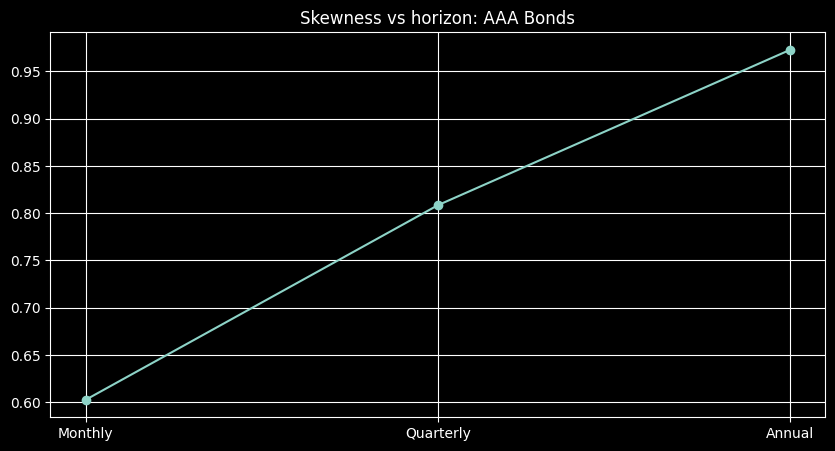

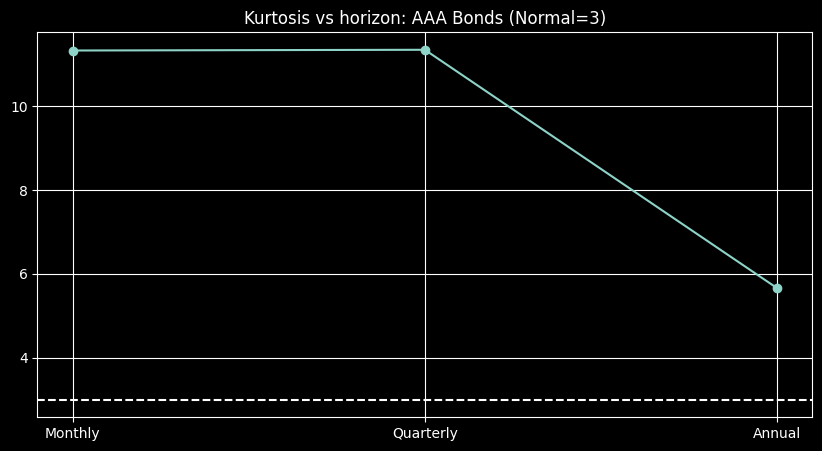

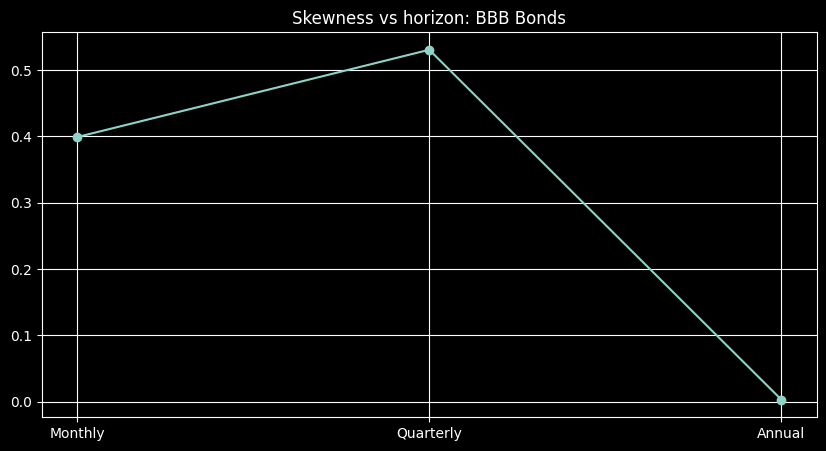

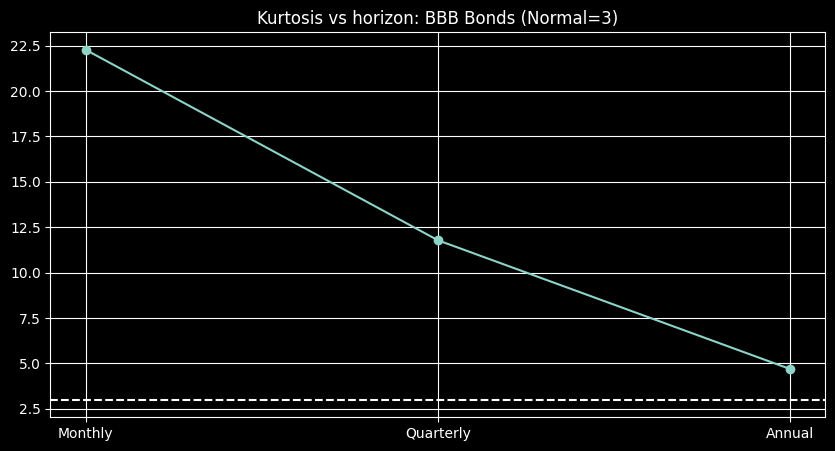

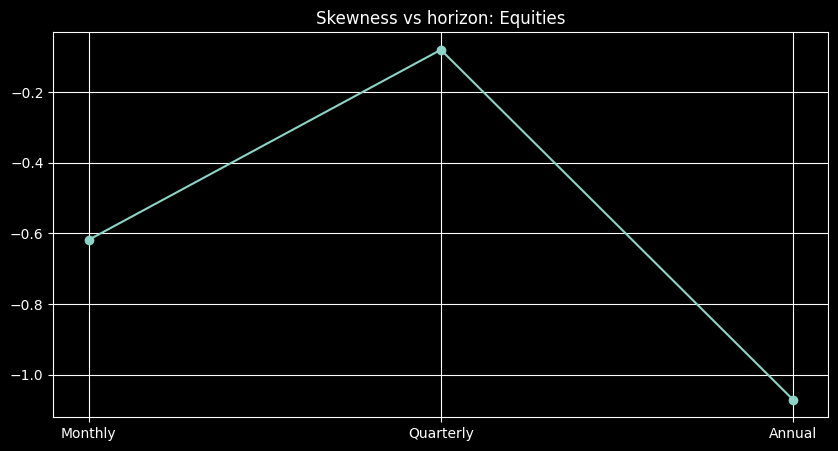

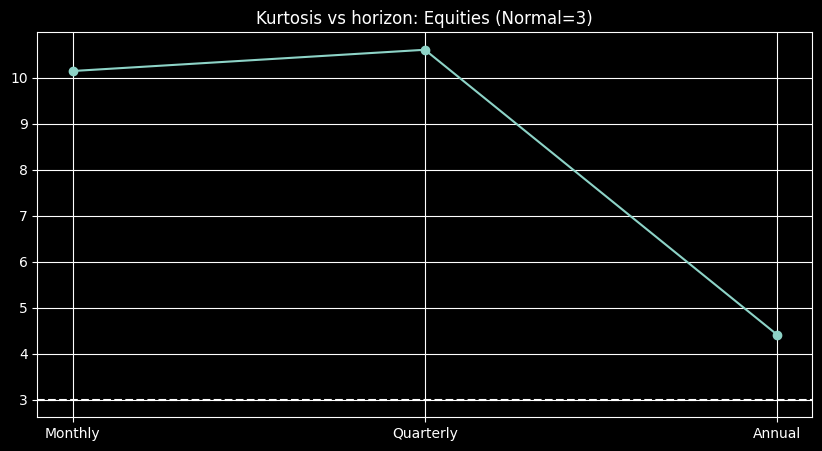

In [23]:
assets = low_m.columns.tolist()

for a in assets:
    s = [mom_m.loc[a,"M_skewness"], mom_q.loc[a,"Q_skewness"], mom_y.loc[a,"Y_skewness"]]
    k = [mom_m.loc[a,"M_kurtosis"], mom_q.loc[a,"Q_kurtosis"], mom_y.loc[a,"Y_kurtosis"]]
    plt.figure()
    plt.plot(["Monthly","Quarterly","Annual"], s, marker="o")
    plt.title(f"Skewness vs horizon: {a}")
    plt.show()

    plt.figure()
    plt.plot(["Monthly","Quarterly","Annual"], k, marker="o")
    plt.axhline(3.0, linestyle="--")
    plt.title(f"Kurtosis vs horizon: {a} (Normal=3)")
    plt.show()


## 5. Portfolio implication — horizon and equity share (Campbell–Shiller intuition)

### 5.1 Why horizon can matter
If returns are i.i.d., then the variance of cumulative k-period returns scales linearly with k:

$
\mathrm{Var}\left(\sum_{t=1}^k r_t\right)=k\,\sigma^2
$

If returns display **mean reversion** (negative autocovariances), then:

$
\mathrm{Var}\left(\sum_{t=1}^k r_t\right)=k\,\gamma_0 + 2\sum_{j=1}^{k-1}(k-j)\,\gamma_j
$

When the sum of autocovariances is negative, long-horizon risk grows **less than linearly** ⇒
**risk per unit time declines** ⇒ **optimal equity weight can increase with horizon** (under mean-variance / normal approximations).

We illustrate this with the long-run dataset (Equities vs AAA Bonds).


In [24]:
# Pick two assets (edit if you want)
eq = "Equities"
bd = "AAA Bonds"

r = low_m[[eq, bd]].dropna()
r.head()


,Equities,AAA Bonds
1928-01-31,-0.510929,0.370978
1928-02-29,-1.780122,0.370978
1928-03-31,11.067660,0.370978
1928-04-30,2.408520,0.370978
1928-05-31,1.257878,0.131580


### 5.2 Long-horizon variance and variance ratios

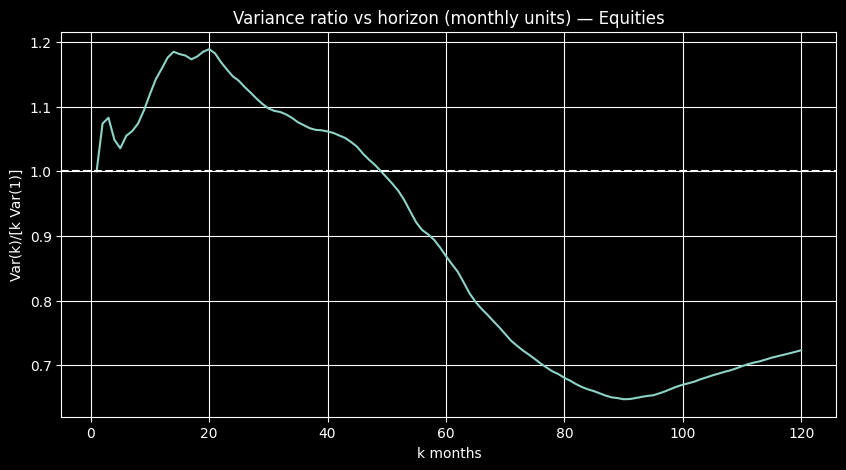

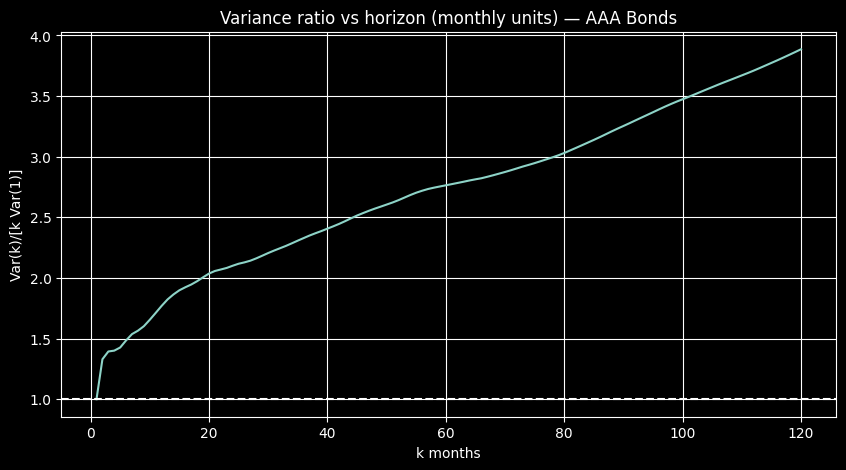

In [25]:
def k_period_returns(ret: pd.DataFrame, k: int) -> pd.DataFrame:
    # overlapping k-month log-returns: sum of monthly log-returns
    return ret.rolling(k).sum().dropna()

def long_horizon_var_ratios(ret_1: pd.Series, max_k: int = 60) -> pd.DataFrame:
    # Variance ratio: Var(k-period)/ (k*Var(1-period))
    v1 = ret_1.var(ddof=0)
    rows = []
    for k in range(1, max_k+1):
        rk = ret_1.rolling(k).sum().dropna()
        vk = rk.var(ddof=0)
        rows.append({"k": k, "var_k": vk, "var_ratio": vk/(k*v1)})
    return pd.DataFrame(rows).set_index("k")

vr_eq = long_horizon_var_ratios(r[eq], max_k=120)  # up to 10 years
vr_bd = long_horizon_var_ratios(r[bd], max_k=120)

plt.figure()
plt.plot(vr_eq.index, vr_eq["var_ratio"])
plt.axhline(1.0, linestyle="--")
plt.title("Variance ratio vs horizon (monthly units) — Equities")
plt.xlabel("k months")
plt.ylabel("Var(k)/[k Var(1)]")
plt.show()

plt.figure()
plt.plot(vr_bd.index, vr_bd["var_ratio"])
plt.axhline(1.0, linestyle="--")
plt.title("Variance ratio vs horizon (monthly units) — AAA Bonds")
plt.xlabel("k months")
plt.ylabel("Var(k)/[k Var(1)]")
plt.show()


## 6) Long-only allocations across horizons

We provide two robust long-only didactic solutions:

### A) Long-only Minimum Variance
$
\min_w\; w^T\Sigma_k w \quad s.c.\quad \sum_i w_i = 1,\; w_i \ge 0
$

### B) Long-only Target Return (Mean–Variance flavour)
$
\min_w\; w^T\Sigma_k w \quad s.c.\quad \mu_k^T w \ge \bar r_k,\; \sum_i w_i = 1,\; w_i \ge 0
$

Both are solved with **SLSQP** (SciPy).


In [ ]:
def long_only_minvar_weights(Sigma: np.ndarray) -> np.ndarray:
    n = Sigma.shape[0]
    x0 = np.ones(n) / n

    def obj(w):
        return float(w @ Sigma @ w)

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n

    res = minimize(obj, x0=x0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")
    return res.x


def minvar_weights_by_horizon(ret_m: pd.DataFrame, horizons: Sequence[int]) -> pd.DataFrame:
    out = []
    for k in horizons:
        rk = k_period_returns(ret_m, k)
        Sigma_k = rk.cov().values
        w = long_only_minvar_weights(Sigma_k)
        out.append({"horizon_months": k, **{ret_m.columns[i]: w[i] for i in range(len(w))}})
    return pd.DataFrame(out).set_index("horizon_months")


In [ ]:
def long_only_target_return_weights(mu: np.ndarray, Sigma: np.ndarray, target: float) -> np.ndarray:
    n = len(mu)
    x0 = np.ones(n) / n

    def obj(w):
        return float(w @ Sigma @ w)

    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: float(w @ mu) - target},  # >= 0
    ]
    bounds = [(0.0, 1.0)] * n

    res = minimize(obj, x0=x0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")
    return res.x


def target_return_weights_by_horizon(ret_m: pd.DataFrame, horizons: Sequence[int], target_1m: float) -> pd.DataFrame:
    out = []
    for k in horizons:
        rk = k_period_returns(ret_m, k)
        mu_k = rk.mean().values          # k-month expected returns (sample mean)
        Sigma_k = rk.cov().values
        target_k = target_1m * k         # simple didactic scaling with horizon
        w = long_only_target_return_weights(mu_k, Sigma_k, target=target_k)
        out.append({"horizon_months": k, **{ret_m.columns[i]: w[i] for i in range(len(w))}})
    return pd.DataFrame(out).set_index("horizon_months")


## 7) Run allocations and plot equity weight vs horizon

In [ ]:
horizons = [1, 3, 6, 12, 24, 36, 60, 120]  # 1m to 10y

# A) Long-only minimum variance
w_lo_minvar = minvar_weights_by_horizon(r, horizons=horizons)
w_lo_minvar


In [ ]:
plt.figure()
plt.plot(w_lo_minvar.index, w_lo_minvar[eq], marker="o")
plt.title("Long-only Min-Var: weight on Equities vs horizon")
plt.xlabel("Horizon (months)")
plt.ylabel("Equity weight")
plt.show()


In [ ]:
# B) Long-only target return (choose a reasonable monthly target)
# Example: 0.2% per month (adjust if infeasible for some horizons in your sample)
w_lo_target = target_return_weights_by_horizon(r, horizons=horizons, target_1m=0.2)
w_lo_target


In [ ]:
plt.figure()
plt.plot(w_lo_target.index, w_lo_target[eq], marker="o")
plt.title("Long-only Target-Return: weight on Equities vs horizon")
plt.xlabel("Horizon (months)")
plt.ylabel("Equity weight")
plt.show()
